In [ ]:
# All pre-installed in Colab, just import
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import pandas as pd
from google.colab import files

In [ ]:
# Run this cell → it will show an "Upload" button
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"Uploaded: {filename}")

Saving jewellery.jpeg to jewellery (1).jpeg
Uploaded: jewellery (1).jpeg


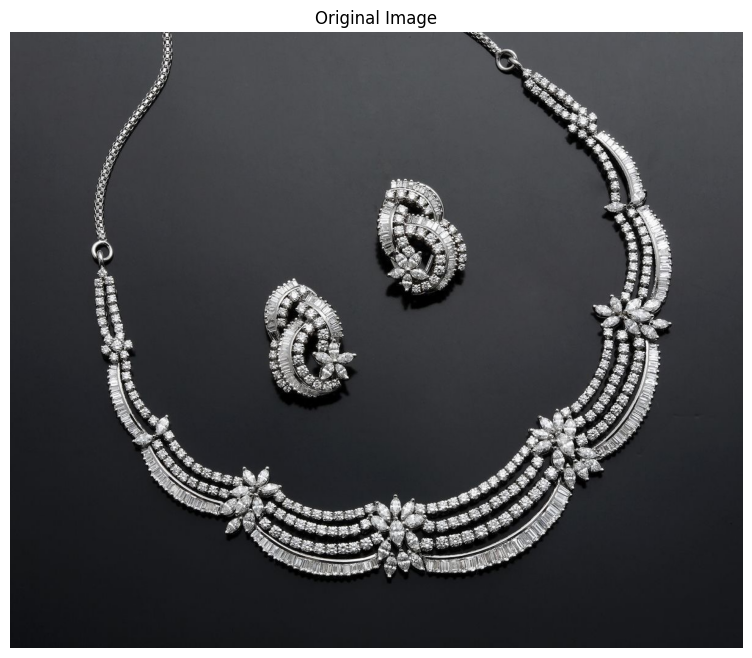

Image Size: 1200W x 1009H pixels


In [ ]:
# Load image
img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Show original
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

print(f"Image Size: {img.shape[1]}W x {img.shape[0]}H pixels")

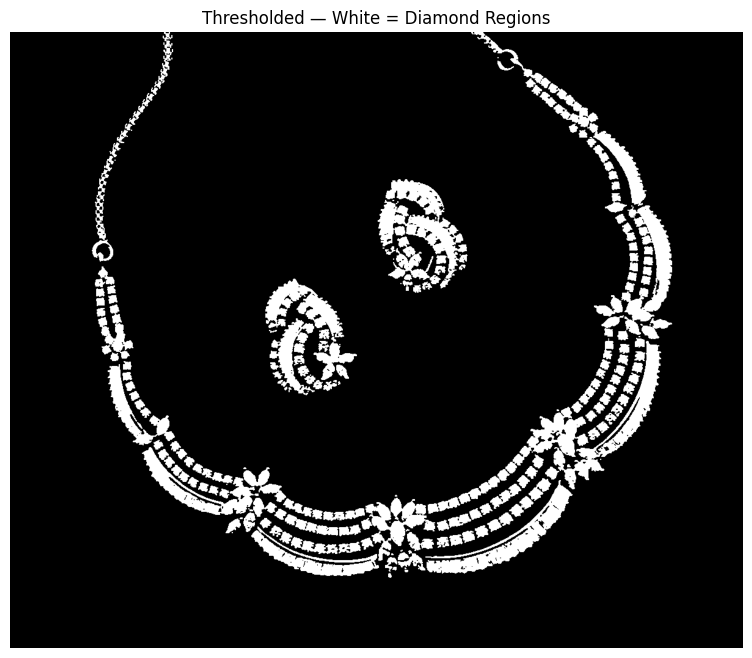

In [ ]:
# Blur to reduce sparkle noise
blur = cv2.GaussianBlur(gray, (3, 3), 0)

# Otsu thresholding — auto finds best cutoff
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Remove tiny noise
kernel = np.ones((2, 2), np.uint8)
thresh_clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

# Show threshold result
plt.figure(figsize=(10, 8))
plt.imshow(thresh_clean, cmap='gray')
plt.title("Thresholded — White = Diamond Regions")
plt.axis('off')
plt.show()

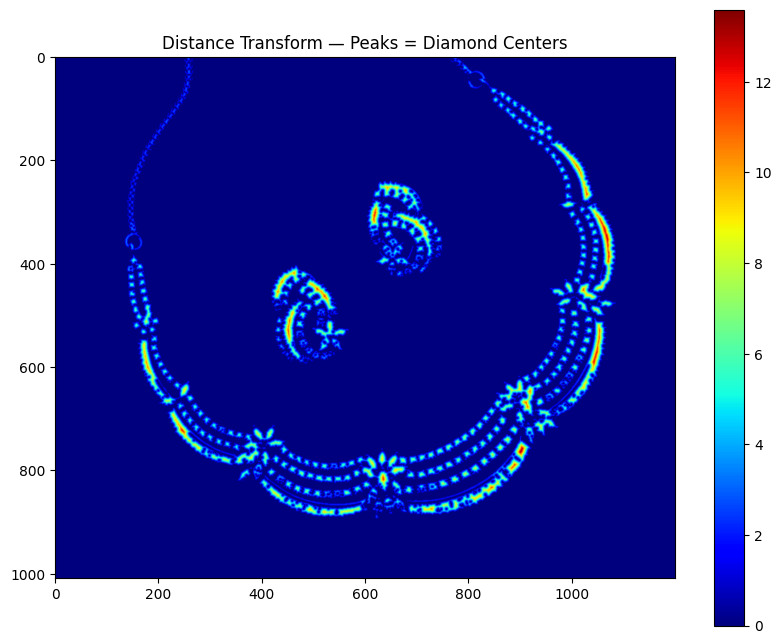

In [ ]:
# Distance transform — finds center of each diamond
dist_transform = cv2.distanceTransform(thresh_clean, cv2.DIST_L2, 5)

# Peak = definite diamond center
_, sure_fg = cv2.threshold(dist_transform, 0.3 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Unknown region (boundaries between diamonds)
sure_bg = cv2.dilate(thresh_clean, kernel, iterations=2)
unknown = cv2.subtract(sure_bg, sure_fg)

# Label markers for watershed
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# Apply watershed
img_watershed = img.copy()
markers = cv2.watershed(img_watershed, markers)

# Show distance transform
plt.figure(figsize=(10, 8))
plt.imshow(dist_transform, cmap='jet')
plt.title("Distance Transform — Peaks = Diamond Centers")
plt.colorbar()
plt.show()

In [ ]:
results = []

# Get unique labels (each label = one diamond)
unique_labels = np.unique(markers)
unique_labels = unique_labels[unique_labels > 1]  # Remove background (-1) and border (1)

for label in unique_labels:
    # Mask for this diamond
    mask = np.zeros(gray.shape, dtype=np.uint8)
    mask[markers == label] = 255

    # Find contour of this diamond
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        continue

    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)

    # Filter out tiny noise (less than 20 sq pixels)
    if area < 20:
        continue

    # Bounding box → width & height
    x, y, w, h = cv2.boundingRect(cnt)

    # Rotated bounding box (better for diagonal baguettes)
    rect = cv2.minAreaRect(cnt)
    rot_w, rot_h = rect[1]

    # Classify cut by shape
    aspect_ratio = max(w, h) / (min(w, h) + 1e-5)
    if aspect_ratio > 2.5:
        cut_type = "Baguette"
    elif aspect_ratio > 1.5:
        cut_type = "Marquise"
    else:
        cut_type = "Round"

    results.append({
        "Diamond #": len(results) + 1,
        "Cut Type": cut_type,
        "X (px)": x,
        "Y (px)": y,
        "Width (px)": round(rot_w, 1),
        "Height (px)": round(rot_h, 1),
        "Area (px²)": round(area, 1)
    })

print(f"\n✅ Total Diamonds Detected: {len(results)}")


✅ Total Diamonds Detected: 279


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


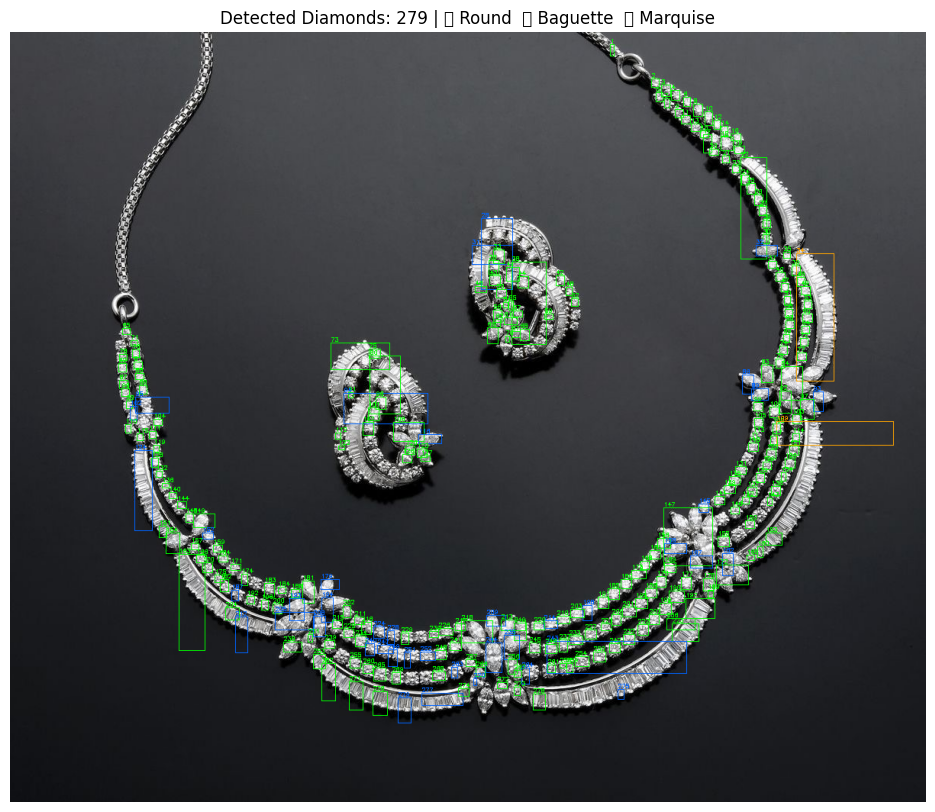

In [ ]:
output = img_rgb.copy()

for r in results:
    x, y, w, h = int(r["X (px)"]), int(r["Y (px)"]), int(r["Width (px)"]), int(r["Height (px)"])

    # Color by cut type
    color = {"Round": (0, 255, 0), "Baguette": (255, 165, 0), "Marquise": (0, 100, 255)}.get(r["Cut Type"], (255,0,0))

    cv2.rectangle(output, (x, y), (x + w, y + h), color, 1)
    cv2.putText(output, str(r["Diamond #"]), (x, y - 2),
                cv2.FONT_HERSHEY_SIMPLEX, 0.25, color, 1)

plt.figure(figsize=(14, 10))
plt.imshow(output)
plt.title(f"Detected Diamonds: {len(results)} | 🟢 Round  🟠 Baguette  🔵 Marquise")
plt.axis('off')
plt.show()

In [ ]:
df = pd.DataFrame(results)

# Summary stats
print("\n📊 Summary by Cut Type:")
print(df.groupby("Cut Type").agg(
    Count=("Diamond #", "count"),
    Avg_Width=("Width (px)", "mean"),
    Avg_Height=("Height (px)", "mean")
).round(1))

print("\n📋 All Diamonds:")
print(df.to_string(index=False))

# Download CSV
df.to_csv("diamond_measurements.csv", index=False)
files.download("diamond_measurements.csv")
print("\n✅ CSV downloaded!")